# 04-1 로지스틱 회귀(LogisticRegression)

In [204]:
import pandas as pd

fish = pd.read_csv('./data/fish.csv')
fish

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...
154,Smelt,12.2,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,14.3,15.2,2.8728,2.0672


In [205]:
#어떤 종류의 생선이 있는지 Species열에서 고유한 값을 추출해보자

pd.unique(fish['Species'])

<StringArray>
['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt']
Length: 7, dtype: str

In [206]:
# Roach : 잉어과의 물고기
# Whitefish : 송어
# Parkki : 돔
# Pike : 꼬치고기

✔ 특성과 타깃 분리

In [207]:
#species열을 타킷으로 만들고 나머지 5개의 열은 입력 데이터로 사용하자

fish_input =fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']].to_numpy()

In [208]:
fish_input[:5]

array([[242.    ,  25.4   ,  30.    ,  11.52  ,   4.02  ],
       [290.    ,  26.3   ,  31.2   ,  12.48  ,   4.3056],
       [340.    ,  26.5   ,  31.1   ,  12.3778,   4.6961],
       [363.    ,  29.    ,  33.5   ,  12.73  ,   4.4555],
       [430.    ,  29.    ,  34.    ,  12.444 ,   5.134 ]])

In [209]:
type(fish_input)

numpy.ndarray

In [210]:
fish_input.shape

(159, 5)

In [211]:
#타킷 데이터를 만든다.
fish_target = fish['Species'].to_numpy()
fish_target[:5]

array(['Bream', 'Bream', 'Bream', 'Bream', 'Bream'], dtype=object)

✔ 훈련 / 테스트 세트 분리

In [212]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(
    fish_input,
    fish_target,
    random_state=42
)

In [213]:
train_input[:10]

array([[720.    ,  35.    ,  40.6   ,  16.3618,   6.09  ],
       [500.    ,  45.    ,  48.    ,   6.96  ,   4.896 ],
       [  7.5   ,  10.5   ,  11.6   ,   1.972 ,   1.16  ],
       [110.    ,  22.    ,  23.5   ,   5.5225,   3.995 ],
       [140.    ,  20.7   ,  23.2   ,   8.5376,   3.2944],
       [ 69.    ,  18.2   ,  20.3   ,   5.2983,   2.8217],
       [110.    ,  21.    ,  22.5   ,   5.6925,   3.555 ],
       [620.    ,  34.5   ,  39.7   ,  15.5227,   5.2801],
       [130.    ,  21.3   ,  22.8   ,   6.384 ,   3.534 ],
       [ 85.    ,  20.    ,  21.    ,   5.082 ,   2.772 ]])

In [214]:
train_target[:10]

array(['Bream', 'Pike', 'Smelt', 'Perch', 'Parkki', 'Roach', 'Perch',
       'Bream', 'Perch', 'Perch'], dtype=object)

## 📌 표준화 (중요 ⭐)

In [215]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()  #데이터를 평균 0, 표준편차 1로 변환하는 스케일링 방법 => 표준화
ss.fit(train_input)   #학습(평균과 표준편차를 학습)

#그 통계값을 이용해 데이터를 변환(스케일링) 하는 단계
train_scaled = ss.transform(train_input)  # 실제변환
test_scaled = ss.transform(test_input)

In [216]:
train_scaled[:5]

array([[ 0.91965782,  0.60943175,  0.81041221,  1.85194896,  1.00075672],
       [ 0.30041219,  1.54653445,  1.45316551, -0.46981663,  0.27291745],
       [-1.0858536 , -1.68646987, -1.70848587, -1.70159849, -2.0044758 ],
       [-0.79734143, -0.60880176, -0.67486907, -0.82480589, -0.27631471],
       [-0.71289885, -0.73062511, -0.70092664, -0.0802298 , -0.7033869 ]])

# 2️⃣ k-최근접 이웃 분류기의 확률 예측

- KNeighborsClassifier 클래스 객체를 만들고 훈련세트로 모델을 훈련한 다음 훈련세트와 테스트 점수를 확인해 보자

In [217]:
from sklearn.neighbors import KNeighborsClassifier

kn = KNeighborsClassifier(n_neighbors=3)

kn.fit(train_scaled, train_target)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [218]:
#스코아 확인
print("훈련 : ", kn.score(train_scaled, train_target))
print("테스트 : ", kn.score(test_scaled, test_target))

훈련 :  0.8907563025210085
테스트 :  0.85


In [219]:
#타깃 데이터를 만들때 fish['Species']를 사용해 만들었기 때문에 훈련 세트와 테스트 세트의 타깃 데이터도 7개의 생선종류가 들어 있다.
#타킷 데이터에 2개 이상의 클래스가 포함된 문제를 다중분류(multiclass classfication)라고 부른다.

In [220]:
#타깃값 전달한것 확인
pd.unique(fish_target)

array(['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt'],
      dtype=object)

In [221]:
#KNeighborsClassifier에서 정렬된 타깃값 확인
kn.classes_

array(['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish'],
      dtype=object)

In [222]:
#테스트세트에 있는 처음 5개의 타깃값을 예측해 보자
kn.predict(test_scaled[:5])

array(['Perch', 'Smelt', 'Pike', 'Perch', 'Perch'], dtype=object)

In [223]:
#5개 샘플에 대한 예측은 어떤 확률로 만들어졌을까요?
#사이킷런의 분류 모델은 predict_proba()메서드로 클래스별 확률값을 반환한다.

## 📌 확률 예측

In [224]:
import numpy as np

proba = kn.predict_proba(test_scaled[:5])
np.round(proba, decimals=4)  #소수점4자리까지 표기

array([[0.    , 0.    , 1.    , 0.    , 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , 0.    , 0.    , 1.    , 0.    ],
       [0.    , 0.    , 0.    , 1.    , 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.6667, 0.    , 0.3333, 0.    , 0.    ],
       [0.    , 0.    , 0.6667, 0.    , 0.3333, 0.    , 0.    ]])

In [225]:
# ['Perch', 'Smelt', 'Pike', 'Perch', 'Perch']

In [226]:
#네 번째 샘플의 최근접이웃을 확인해 보자
distance, indexes = kn.kneighbors(test_scaled[3:4])
train_target[indexes]

# ? ? Perch  Pike Roach Smelt ?
# 네 번째 샘플 Perch의 확률은 2/3,  최근접이웃 Roach 1/3

array([['Roach', 'Perch', 'Perch']], dtype=object)

In [227]:
#확률이라고 하기엔 너무 단순하다. 더 좋은 방법을 찾아보자

# 3️⃣ 로지스틱 회귀

In [228]:
# 시그모이드함수
# z = a*무게 + b * 길이 + c * 대각선 + d * 높이 + e * 두께 + f

# a, b, c, d, e는 가중치 혹은 계수
# f는 절편

# z의 값은 어떤 값도 가능, 하지만 확률이 되려면 0 ~1(또는 0~100%)사이의 값이 되어야 한다.
# Z가 아주 큰 음수일때 0이 되고, Z가 아주 큰 양수일때 1이 되도록 바꾸어주어야 한다. => 시그모이드함수(또는 로지스틱 함수)
# 시그모이드 값이 0.5를 기준으로 양성, 음성

# z → x축 (입력값)
# σ(z) → y축 (확률)

In [229]:
z = np.arange(-5, 5, 0.1)
z

array([-5.00000000e+00, -4.90000000e+00, -4.80000000e+00, -4.70000000e+00,
       -4.60000000e+00, -4.50000000e+00, -4.40000000e+00, -4.30000000e+00,
       -4.20000000e+00, -4.10000000e+00, -4.00000000e+00, -3.90000000e+00,
       -3.80000000e+00, -3.70000000e+00, -3.60000000e+00, -3.50000000e+00,
       -3.40000000e+00, -3.30000000e+00, -3.20000000e+00, -3.10000000e+00,
       -3.00000000e+00, -2.90000000e+00, -2.80000000e+00, -2.70000000e+00,
       -2.60000000e+00, -2.50000000e+00, -2.40000000e+00, -2.30000000e+00,
       -2.20000000e+00, -2.10000000e+00, -2.00000000e+00, -1.90000000e+00,
       -1.80000000e+00, -1.70000000e+00, -1.60000000e+00, -1.50000000e+00,
       -1.40000000e+00, -1.30000000e+00, -1.20000000e+00, -1.10000000e+00,
       -1.00000000e+00, -9.00000000e-01, -8.00000000e-01, -7.00000000e-01,
       -6.00000000e-01, -5.00000000e-01, -4.00000000e-01, -3.00000000e-01,
       -2.00000000e-01, -1.00000000e-01, -1.77635684e-14,  1.00000000e-01,
        2.00000000e-01,  

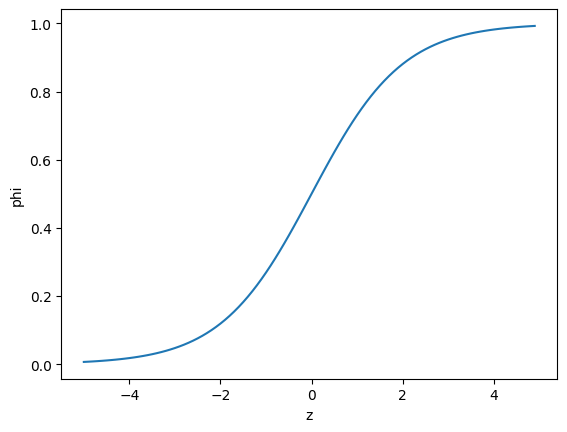

In [230]:
#위의 차트를 그려보자

import numpy as np
import matplotlib.pyplot as plt

z = np.arange(-5, 5, 0.1)
phi = 1 / (1+np.exp(-z))
plt.plot(z, phi)
plt.xlabel('z')
plt.ylabel('phi')
plt.show()

# 4️⃣ 로지스틱 회귀로 이진 분류 수행하기

In [231]:
# 훈련하기 전 간단한 이진분류를 사용하여 수행해보자
# 시그모이드 함수의 출력이 0.5보다 크면 양성 클래스, 0.5보다 작으면 음성 클래스로 판단한다.
# 도미(Bream)와 빙어(Smelt) 2개를 사용한다.

In [232]:
bream_smelt_indexes = (train_target == 'Bream') | (train_target == 'Smelt')
train_bream_smelt = train_scaled[bream_smelt_indexes]
train_bream_smelt

target_bream_smelt = train_target[bream_smelt_indexes]
target_bream_smelt

array(['Bream', 'Smelt', 'Bream', 'Bream', 'Bream', 'Smelt', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Smelt',
       'Bream', 'Smelt', 'Smelt', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Smelt', 'Bream', 'Smelt',
       'Smelt', 'Bream', 'Smelt', 'Bream', 'Bream'], dtype=object)

In [233]:
train_bream_smelt[0,]

array([0.91965782, 0.60943175, 0.81041221, 1.85194896, 1.00075672])

## 📌 모델 학습

In [234]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(train_bream_smelt, target_bream_smelt)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [235]:
#훈련한 모델을 사용해 train_bream_smelt에 있는 처음 5개의 샘플을 예측해 보자
lr.predict(train_bream_smelt[:5])

array(['Bream', 'Smelt', 'Bream', 'Bream', 'Bream'], dtype=object)

In [236]:
#두 번째 샘플만 빙어(Smelt)이고 나머지는 모두 도미(Bream)이다
lr.predict_proba(train_bream_smelt[:5])


# 0.00239993, 0.97262675, 0.00513614, 0.01414953, 0.00232581

array([[0.99760007, 0.00239993],
       [0.02737325, 0.97262675],
       [0.99486386, 0.00513614],
       [0.98585047, 0.01414953],
       [0.99767419, 0.00232581]])

In [237]:
#첫번째 열이 음성클래스(0)에 대한 확률이고 두번째 열이 양성클래스(1)에 대한 확률이다.

In [238]:
# 첫번째 클래스가 누구일까? classes_확인하자
lr.classes_

array(['Bream', 'Smelt'], dtype=object)

In [239]:
#로지스틱 회귀가 학습한 계수(coef), 절편(intercept)를 확인해 보자
lr.coef_, lr.intercept_

(array([[-0.40451732, -0.57582787, -0.66248158, -1.01329614, -0.73123131]]),
 array([-2.16172774]))

In [240]:
train_bream_smelt[0,]

array([0.91965782, 0.60943175, 0.81041221, 1.85194896, 1.00075672])

In [241]:
# z = a*무게 + b * 길이 + c * 대각선 + d * 높이 + e * 두께 + f
(-0.40451732*0.91965782) + (-0.57582787*0.60943175) + (-0.66248158*0.81041221) + (-1.01329614 * 1.85194896) + (-0.73123131 * 1.00075672) + (-2.16172774)

-6.029913584510324

## 📌 decision_function()

- ✔ z값 반환

- ✔ 이 값을 시그모이드에 넣으면 확률

In [242]:
decisions = lr.decision_function(train_bream_smelt[:5])
decisions

array([-6.02991358,  3.57043428, -5.26630496, -4.24382314, -6.06135688])

In [243]:
# 양수일수록 → 양성 클래스(positive class)일 가능성이 높음
# 음수일수록 → 음성 클래스(negative class)일 가능성이 높음
# 절댓값이 클수록 → 모델이 자신 있게 판단했다는 뜻

In [244]:
from scipy.special import expit

expit(decisions)

# prodict_proba()메서드의 두번째 출력값과 동일하다
# decisions_function()는 양성클래스에 대한 z값을 반환한다는 것을 알 수 있다.

array([0.00239993, 0.97262675, 0.00513614, 0.01414953, 0.00232581])

# 5️⃣ 로지스틱 회귀로 다중 분류 수행하기

In [245]:
# max_iter는 반복횟수, 기본값은 100
# 릿지회귀는 alpha값으로 규제함, 로지스틱회귀는 C로 규제함, 기본값은 1임, 값이 작을 수록 규제가 커진다.
# C=20으로 규제를 완화함, C는 규제를 조절하는 하이퍼파라미터

lr = LogisticRegression(C=20, max_iter=1000)
lr.fit(train_scaled, train_target)

print("train :", lr.score(train_scaled, train_target))
print("test : ", lr.score(test_scaled, test_target))

train : 0.9327731092436975
test :  0.925


In [246]:
# 테스트세트의 처음 5개의 샘플에 대한 예측
lr.predict(test_scaled[:5])

array(['Perch', 'Smelt', 'Pike', 'Roach', 'Perch'], dtype=object)

In [247]:
# 테스트 세트의 처음 5개 샘플에 대한 예측 확률 출력
proba = lr.predict_proba(test_scaled[:5])
np.round(proba,decimals=3)

array([[0.   , 0.014, 0.842, 0.   , 0.135, 0.007, 0.003],
       [0.   , 0.003, 0.044, 0.   , 0.007, 0.946, 0.   ],
       [0.   , 0.   , 0.034, 0.934, 0.015, 0.016, 0.   ],
       [0.011, 0.034, 0.305, 0.006, 0.567, 0.   , 0.076],
       [0.   , 0.   , 0.904, 0.002, 0.089, 0.002, 0.001]])

In [248]:
#1행의 3번째 0.842, 이 생선은 Perch(농어)일까? classes_속성을 확인해 보자
lr.classes_

array(['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish'],
      dtype=object)

## 📌 coef_ 구조

In [249]:
#coef_와 intercept_의 크기를 보면 7행5열, 절편도 7행, Z값도 7개라는 뜻이다

lr.coef_.shape, lr.intercept_.shape

((7, 5), (7,))

In [252]:
lr.coef_

array([[-1.50605455, -1.03747913,  2.60919713,  7.69422739, -1.18603342],
       [ 0.19200047, -1.99988812, -3.79617725,  6.50312639, -2.00022754],
       [ 3.55793539,  6.36988929, -8.52233732, -5.75397233,  3.79233438],
       [-0.11453308,  3.61060121,  3.94464503, -3.62243904, -1.7598168 ],
       [-1.40843717, -6.09242191,  5.28629633, -0.86696569,  1.84518455],
       [-1.33419952,  1.48153392,  1.38217547, -5.6602348 , -4.39228963],
       [ 0.61328846, -2.33223527, -0.90379939,  1.70625807,  3.70084846]])

In [253]:
lr.coef_[0]

array([-1.50605455, -1.03747913,  2.60919713,  7.69422739, -1.18603342])

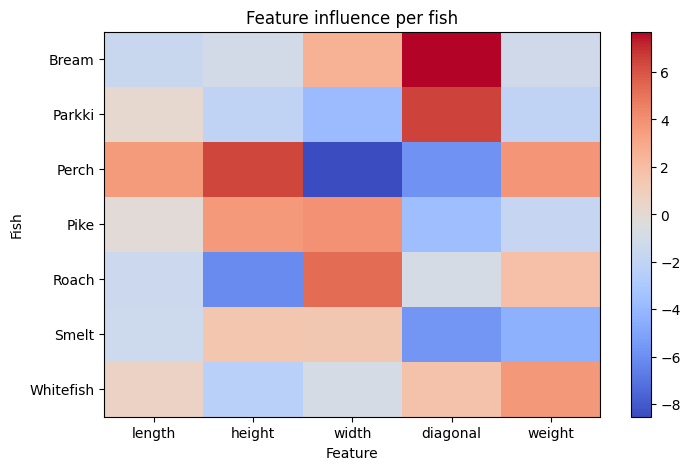

In [256]:
features = ["length","height","width","diagonal","weight"]

plt.figure(figsize=(8,5))
plt.imshow(lr.coef_, cmap="coolwarm", aspect="auto")
plt.colorbar()

plt.xticks(range(len(features)), features)
plt.yticks(range(len(lr.classes_)), lr.classes_)

plt.xlabel("Feature")
plt.ylabel("Fish")
plt.title("Feature influence per fish")

plt.show()


In [250]:
# 확률계산은 어떻게 할까? 이진분류에서는 시그모이드함수를 사용해 Z를 0과 1사이의 값으로 변환함
# 다중분류에서는 소프트맥스(softmax)함수를 사용하여 7개의 z값을 확률로 변환한다.
# 테스트세트의 처음 5개 샘플에 대한 z1 ~ z7의 값을 구해보자

decisions = lr.decision_function(test_scaled[:5])
np.round(decisions, decimals=2)

array([[ -6.51,   1.04,   5.17,  -2.76,   3.34,   0.35,  -0.63],
       [-10.88,   1.94,   4.78,  -2.42,   2.99,   7.84,  -4.25],
       [ -4.34,  -6.24,   3.17,   6.48,   2.36,   2.43,  -3.87],
       [ -0.69,   0.45,   2.64,  -1.21,   3.26,  -5.7 ,   1.26],
       [ -6.4 ,  -1.99,   5.82,  -0.13,   3.5 ,  -0.09,  -0.7 ]])

In [251]:
from scipy.special import softmax

proba = softmax(decisions, axis=1)
np.round(proba, decimals=3)

array([[0.   , 0.014, 0.842, 0.   , 0.135, 0.007, 0.003],
       [0.   , 0.003, 0.044, 0.   , 0.007, 0.946, 0.   ],
       [0.   , 0.   , 0.034, 0.934, 0.015, 0.016, 0.   ],
       [0.011, 0.034, 0.305, 0.006, 0.567, 0.   , 0.076],
       [0.   , 0.   , 0.904, 0.002, 0.089, 0.002, 0.001]])